## Support Vector Regression (SVR)

In [50]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC, SVR
from sklearn.metrics import classification_report, confusion_matrix, r2_score, mean_squared_error
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler


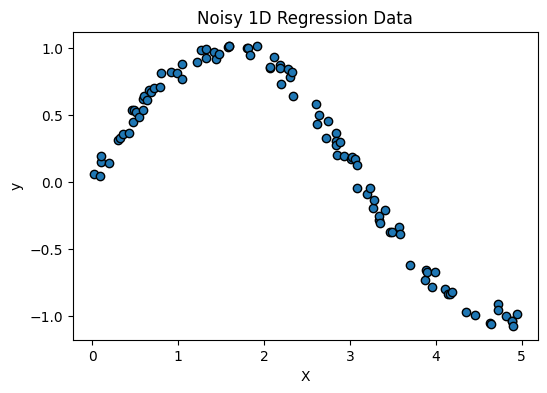

In [51]:
# Create a simple 1D regression dataset
rng = np.random.RandomState(0)
X_reg = np.sort(5 * rng.rand(100, 1), axis=0)
y_reg = np.sin(X_reg).ravel()

# Add some noise 
y_reg += 0.2 * (rng.rand(y_reg.shape[0]) - 0.5)

plt.figure(figsize=(6, 4))
plt.scatter(X_reg, y_reg, edgecolors='k')
plt.xlabel('X')
plt.ylabel('y')
plt.title("Noisy 1D Regression Data")
plt.show()

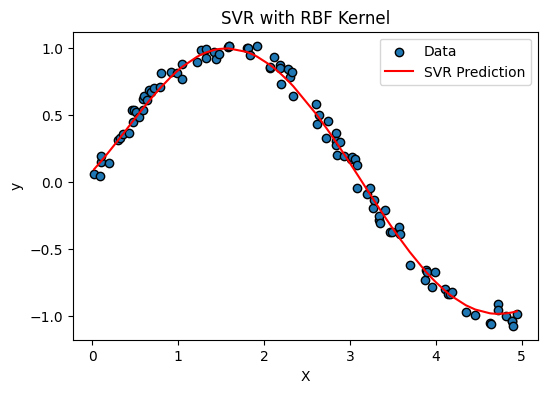

In [52]:
svr_rbf = SVR(kernel='rbf', C=100, gamma='scale', epsilon=.1)
svr_rbf.fit(X_reg, y_reg)
y_pred = svr_rbf.predict(X_reg)

plt.figure(figsize=(6, 4))
plt.scatter(X_reg, y_reg, edgecolors='k', label='Data')
plt.plot(X_reg, y_pred, color='red', label='SVR Prediction')
plt.xlabel('X')
plt.ylabel('y')
plt.title("SVR with RBF Kernel")
plt.legend()
plt.show()

In [53]:
# Evaluate SVR with MSE and R^2
mse = mean_squared_error(y_reg, y_pred)
r2 = r2_score(y_reg, y_pred)

print(f"Mean Squared Error: {mse * 100:.4f}%")
print(f"R^2 Score: {r2 * 100:.2f}%")


Mean Squared Error: 0.3280%
R^2 Score: 99.26%


# SVR on Real Data (Diabetes Dataset)

In [54]:

diabetes = load_diabetes()
x_diabetes = diabetes.data
y_diabetes = diabetes.target

print("Feature shape: ", x_diabetes.shape)
print("Target shape: ", y_diabetes.shape)

Feature shape:  (442, 10)
Target shape:  (442,)


In [55]:
# Train test split  
X_diabetes_train, X_diabetes_test, y_diabetes_train, y_diabetes_test = train_test_split(
    x_diabetes, y_diabetes, test_size=0.2, random_state=42
)

scaler_diabetes = StandardScaler()
X_diabetes_train_scaled = scaler_diabetes.fit_transform(X_diabetes_train)
X_diabetes_test_scaled = scaler_diabetes.transform(X_diabetes_test)

In [59]:
# Train SVR on Diabetes Dataset

# C beshi hoile tight fit hobe, gamma beshi hoile overfitting hobe, epsilon beshi hoile loose fit hobe (less support vectors)

svr_diabetes = SVR(kernel='rbf', C=100, gamma='scale', epsilon=1.0)
svr_diabetes.fit(X_diabetes_train_scaled, y_diabetes_train)

y_diabetes_pred = svr_diabetes.predict(X_diabetes_test_scaled)

mse_diabetes = mean_squared_error(y_diabetes_test, y_diabetes_pred)
r2_diabetes = r2_score(y_diabetes_test, y_diabetes_pred)

print(f"Diabetes Dataset - Mean Squared Error: {mse_diabetes:.4f}")
print(f"Diabetes Dataset - R^2 Score: {r2_diabetes:.2f}")

Diabetes Dataset - Mean Squared Error: 2606.7129
Diabetes Dataset - R^2 Score: 0.51


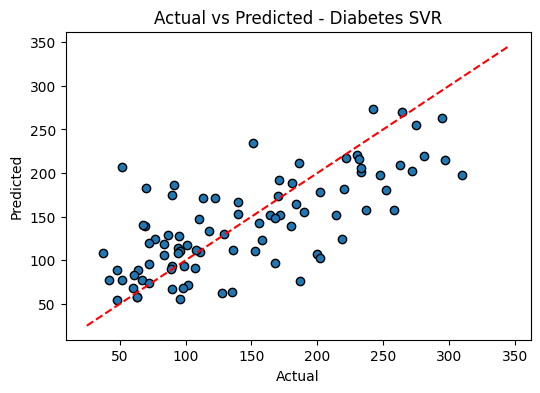

In [60]:
# plotting actual vs predicted
plt.figure(figsize=(6, 4))
plt.scatter(y_diabetes_test, y_diabetes_pred, edgecolors='k')
plt.plot([y_diabetes.min(), y_diabetes.max()], [y_diabetes.min(), y_diabetes.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title("Actual vs Predicted - Diabetes SVR")
plt.show()

In [62]:
# Function to check with different C , gamma and epsilon values and create DF
def evaluate_svr(X_train, y_train, X_test, y_test, C_values, gamma_values, epsilon_values):
    results = []
    for C in C_values:
        for gamma in gamma_values:
            for epsilon in epsilon_values:
                svr = SVR(kernel='rbf', C=C, gamma=gamma, epsilon=epsilon)
                svr.fit(X_train, y_train)
                y_pred = svr.predict(X_test)
                mse = mean_squared_error(y_test, y_pred)
                r2 = r2_score(y_test, y_pred)
                results.append({
                    'C': C,
                    'gamma': gamma,
                    'epsilon': epsilon,
                    'MSE': mse,
                    'R^2': r2
                })
    return pd.DataFrame(results)

C_values = [0.1, 1, 10, 100, 1000]
gamma_values = ['scale', 'auto']
epsilon_values = [0.1, 1, 10, 100]

svr_results = evaluate_svr(X_diabetes_train_scaled, y_diabetes_train, X_diabetes_test_scaled, y_diabetes_test, C_values, gamma_values, epsilon_values)

print(svr_results)
 

         C  gamma  epsilon          MSE       R^2
0      0.1  scale      0.1  5178.142892  0.022651
1      0.1  scale      1.0  5177.543665  0.022764
2      0.1  scale     10.0  5192.311975  0.019977
3      0.1  scale    100.0  5543.408154 -0.046291
4      0.1   auto      0.1  5178.142892  0.022651
5      0.1   auto      1.0  5177.543665  0.022764
6      0.1   auto     10.0  5192.311975  0.019977
7      0.1   auto    100.0  5543.408154 -0.046291
8      1.0  scale      0.1  4332.738479  0.182217
9      1.0  scale      1.0  4316.773270  0.185230
10     1.0  scale     10.0  4278.097699  0.192530
11     1.0  scale    100.0  5089.449088  0.039392
12     1.0   auto      0.1  4332.738479  0.182217
13     1.0   auto      1.0  4316.773270  0.185230
14     1.0   auto     10.0  4278.097699  0.192530
15     1.0   auto    100.0  5089.449088  0.039392
16    10.0  scale      0.1  2682.387950  0.493713
17    10.0  scale      1.0  2678.411061  0.494463
18    10.0  scale     10.0  2694.704100  0.491388
